<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Duplicates Lab**


Estimated time needed: **30** minutes


## Introduction


Data wrangling is a critical step in preparing datasets for analysis, and handling duplicates plays a key role in ensuring data accuracy. In this lab, you will focus on identifying and removing duplicate entries from your dataset. 


## Objectives


In this lab, you will perform the following:


1. Identify duplicate rows in the dataset and analyze their characteristics.
2. Visualize the distribution of duplicates based on key attributes.
3. Remove duplicate values strategically based on specific criteria.
4. Outline the process of verifying and documenting duplicate removal.


## Hands on Lab


Install the needed library


In [1]:
!pip install pandas
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 156.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 160.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 96.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 175.5 MB/s eta 0:00:00


Import pandas module


In [2]:
import pandas as pd


Import matplotlib


In [3]:
import matplotlib.pyplot as plt


## **Load the dataset into a dataframe**


<h2>Read Data</h2>
<p>
We utilize the <code>pandas.read_csv()</code> function for reading CSV files. However, in this version of the lab, which operates on JupyterLite, the dataset needs to be downloaded to the interface using the provided code below.
</p>


In [4]:
# Load the dataset directly from the URL
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/VYPrOu0Vs3I0hKLLjiPGrA/survey-data-with-duplicate.csv"
df = pd.read_csv(file_path)

# Display the first few rows
print(df.head())

   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

Load the data into a pandas dataframe:



Note: If you are working on a local Jupyter environment, you can use the URL directly in the pandas.read_csv() function as shown below:



In [ ]:
# df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv")


## Identify and Analyze Duplicates


### Task 1: Identify Duplicate Rows
1. Count the number of duplicate rows in the dataset.
3. Display the first few duplicate rows to understand their structure.


In [5]:
## Write your code here
# Task 1: Identify Duplicate Rows

# 1) Count duplicate rows (full-row duplicates)
dup_count = df.duplicated().sum()
print("Number of duplicate rows (entire row duplicated):", dup_count)

# 2) Display the first few duplicate rows (all duplicates, not just later occurrences)
dups = df[df.duplicated(keep=False)].sort_values(by=df.columns.tolist())
print("\nFirst 10 duplicate rows (including all occurrences):")
display(dups.head(10))

Number of duplicate rows (entire row duplicated): 20

First 10 duplicate rows (including all occurrences):


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
65437,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
65438,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
65439,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
65440,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN
65441,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 2: Analysis of Duplicate Response Patterns
1. Identify duplicate response patterns based on selected columns such as MainBranch, Employment, and RemoteWork.
2. Clarify that these represent multiple respondents with identical answers rather than duplicate records. Analyse which other columns frequently share identical values within these response-pattern groups.
   


In [6]:
## Write your code here
# Task 2: Analysis of Duplicate Response Patterns

pattern_cols = ["MainBranch", "Employment", "RemoteWork"]

# How many respondents share the same pattern?
pattern_counts = df.groupby(pattern_cols, dropna=False).size().reset_index(name="count")
shared_patterns = pattern_counts[pattern_counts["count"] > 1].sort_values("count", ascending=False)

print("Number of shared response patterns (count > 1):", shared_patterns.shape[0])
display(shared_patterns.head(10))

# Pull rows for the most common shared pattern to inspect
top_pattern = shared_patterns.iloc[0][pattern_cols].to_dict()
print("\nMost common shared pattern:", top_pattern)

pattern_rows = df[
    (df["MainBranch"] == top_pattern["MainBranch"]) &
    (df["Employment"] == top_pattern["Employment"]) &
    (df["RemoteWork"] == top_pattern["RemoteWork"])
]

print("Rows in most common shared pattern group:", len(pattern_rows))
display(pattern_rows.head(5))

# Which other columns tend to be identical within these pattern groups?
# We'll compute, per group, how many columns are constant (nunique == 1) ignoring missing where possible.
def constant_cols_count(group):
    nunq = group.nunique(dropna=True)
    return (nunq == 1).sum()

const_summary = df.groupby(pattern_cols, dropna=False).apply(constant_cols_count).reset_index(name="num_constant_cols")
const_summary = const_summary.merge(pattern_counts, on=pattern_cols)

print("\nGroups with most identical columns (among shared patterns):")
display(const_summary[const_summary["count"] > 1].sort_values(["num_constant_cols","count"], ascending=False).head(10))

Number of shared response patterns (count > 1): 394


,MainBranch,Employment,RemoteWork,count
0,I am a developer by profession,"Employed, full-time","Hybrid (some remote, some in-person)",15288
2,I am a developer by profession,"Employed, full-time",Remote,12196
1,I am a developer by profession,"Employed, full-time",In-person,7118
82,I am a developer by profession,"Independent contractor, freelancer, or self-em...",Remote,2815
9,I am a developer by profession,"Employed, full-time;Independent contractor, fr...",Remote,1754
244,I am learning to code,"Student, full-time",NaN,1543
280,"I am not primarily a developer, but I write co...","Employed, full-time","Hybrid (some remote, some in-person)",1479
111,I am a developer by profession,"Not employed, but looking for work",NaN,1307
456,I code primarily as a hobby,"Student, full-time",NaN,1275
7,I am a developer by profession,"Employed, full-time;Independent contractor, fr...","Hybrid (some remote, some in-person)",1169



Most common shared pattern: {'MainBranch': 'I am a developer by profession', 'Employment': 'Employed, full-time', 'RemoteWork': 'Hybrid (some remote, some in-person)'}
Rows in most common shared pattern group: 15288


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
12,13,I am a developer by profession,35-44 years old,"Employed, full-time","Hybrid (some remote, some in-person)",Apples,Hobby;Contribute to open-source projects;Profe...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;On the job training;Sch...,NaN,...,30.0,0.0,0.0,20.0,10.0,10.0,Appropriate in length,Easy,NaN,8.0
14,15,I am a developer by profession,25-34 years old,"Employed, full-time","Hybrid (some remote, some in-person)",Apples,Hobby;Professional development or self-paced l...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Other online resources ...,Stack Overflow;Coding sessions (live or record...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
15,16,I am a developer by profession,45-54 years old,"Employed, full-time","Hybrid (some remote, some in-person)",Apples,Hobby,Some college/university study without earning ...,Books / Physical media;On the job training;Oth...,Technical documentation;Books;Written Tutorial...,...,0.0,0.0,0.0,0.0,0.0,0.0,Appropriate in length,Neither easy nor difficult,NaN,5.0
18,19,I am a developer by profession,25-34 years old,"Employed, full-time","Hybrid (some remote, some in-person)",Apples,Hobby;Professional development or self-paced l...,Some college/university study without earning ...,Books / Physical media;On the job training;Oth...,Technical documentation;Blogs;Books;Stack Over...,...,60.0,10.0,10.0,0.0,0.0,0.0,Appropriate in length,Easy,NaN,10.0
19,20,I am a developer by profession,35-44 years old,"Employed, full-time","Hybrid (some remote, some in-person)",Apples,Hobby;Professional development or self-paced l...,Some college/university study without earning ...,Books / Physical media;Other online resources ...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Neither easy nor difficult,NaN,NaN



Groups with most identical columns (among shared patterns):


,MainBranch,Employment,RemoteWork,num_constant_cols,count
19,I am a developer by profession,"Employed, full-time;Independent contractor, fr...",In-person,94,2
354,"I am not primarily a developer, but I write co...","Not employed, but looking for work;Employed, p...",In-person,88,2
310,"I am not primarily a developer, but I write co...","Employed, full-time;Student, full-time;Not emp...","Hybrid (some remote, some in-person)",86,2
34,I am a developer by profession,"Employed, full-time;Not employed, but looking ...",Remote,74,2
331,"I am not primarily a developer, but I write co...","Independent contractor, freelancer, or self-em...","Hybrid (some remote, some in-person)",65,2
118,I am a developer by profession,"Not employed, but looking for work;Independent...",NaN,64,3
503,"I used to be a developer by profession, but no...","Employed, full-time;Student, full-time",In-person,64,3
156,I am a developer by profession,"Student, full-time;Not employed, but looking f...","Hybrid (some remote, some in-person)",64,2
496,"I used to be a developer by profession, but no...","Employed, full-time;Independent contractor, fr...","Hybrid (some remote, some in-person)",63,3
346,"I am not primarily a developer, but I write co...","Independent contractor, freelancer, or self-em...",Remote,62,2


### Task 3: Visualize Shared Response Patterns
1. Create visualizations to show the distribution of shared response patterns across different categories.
2. Use bar charts or pie charts to represent the distribution of respondents who share identical values for MainBranch, Employment, and RemoteWork, grouped by Country and Employment.


/tmp/ipykernel_1761/3803447243.py:35: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


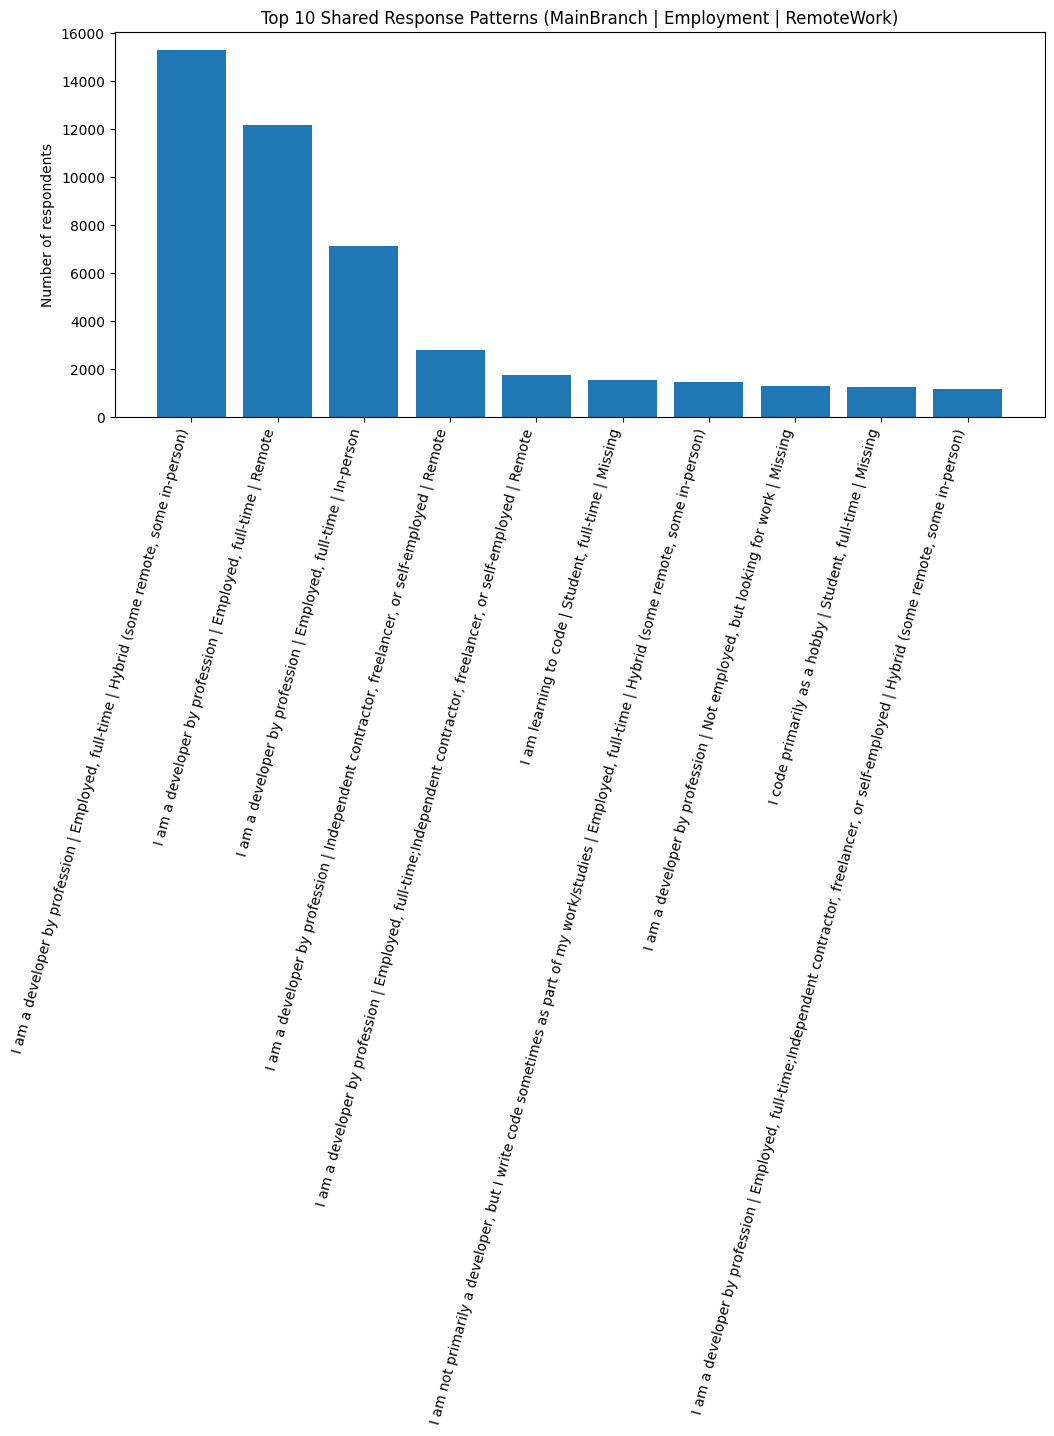

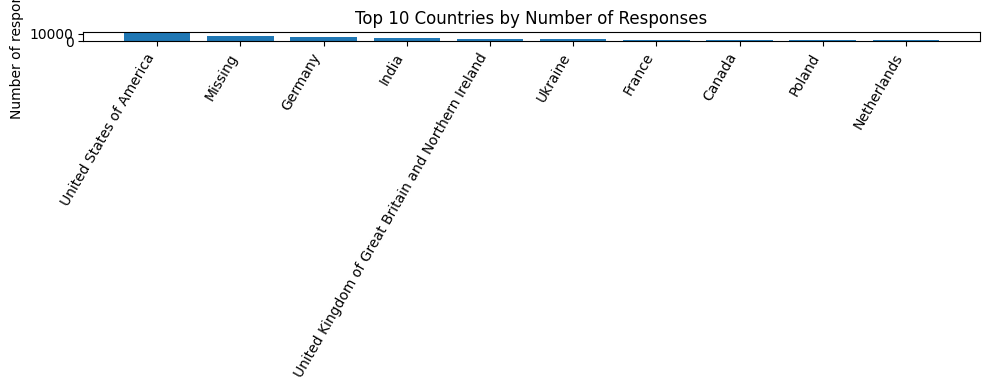

/tmp/ipykernel_1761/3803447243.py:55: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


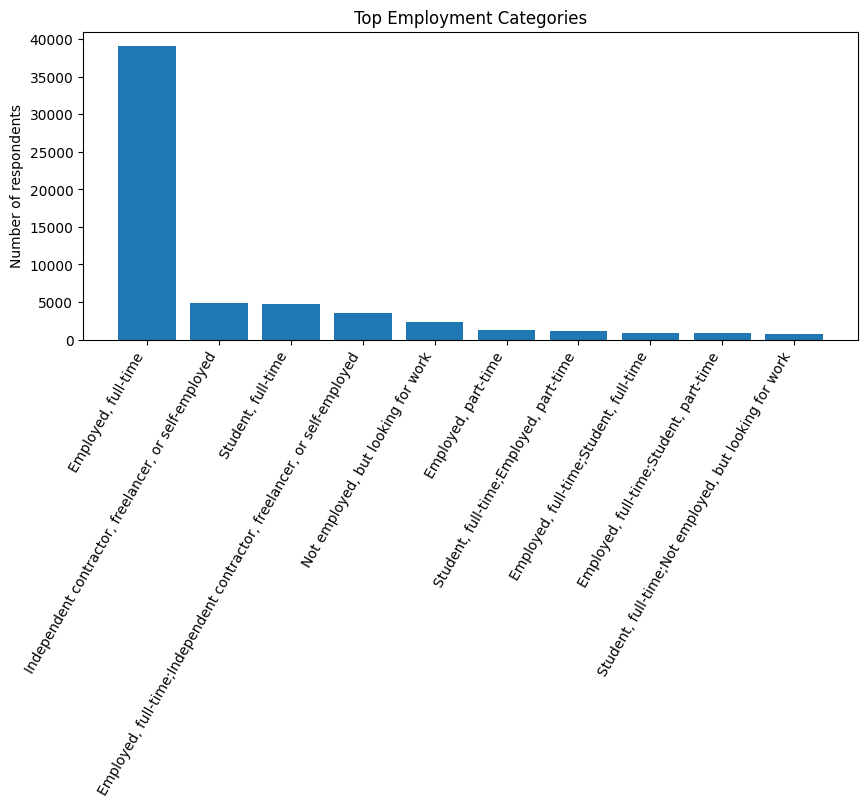

In [8]:
## Write your code here
# Task 3: Visualize Shared Response Patterns (robust to NaN/mixed types)

pattern_cols = ["MainBranch", "Employment", "RemoteWork"]

# Count respondents per pattern
pattern_counts = (
    df.groupby(pattern_cols, dropna=False)
      .size()
      .reset_index(name="count")
      .sort_values("count", ascending=False)
)

top10 = pattern_counts.head(10).copy()

# Fill missing values so we don't get NaN floats in labels
for c in pattern_cols:
    top10[c] = top10[c].fillna("Missing").astype(str)

top10["Pattern"] = (
    top10["MainBranch"] + " | " +
    top10["Employment"] + " | " +
    top10["RemoteWork"]
)

# Convert to plain Python lists (matplotlib-friendly)
x = top10["Pattern"].tolist()
y = top10["count"].tolist()

plt.figure(figsize=(12, 5))
plt.bar(x, y)
plt.xticks(rotation=75, ha="right")
plt.ylabel("Number of respondents")
plt.title("Top 10 Shared Response Patterns (MainBranch | Employment | RemoteWork)")
plt.tight_layout()
plt.show()

# Top 10 countries by responses (handle missing)
country_counts = df["Country"].fillna("Missing").astype(str).value_counts().head(10)
plt.figure(figsize=(10, 4))
plt.bar(country_counts.index.tolist(), country_counts.values.tolist())
plt.xticks(rotation=60, ha="right")
plt.ylabel("Number of respondents")
plt.title("Top 10 Countries by Number of Responses")
plt.tight_layout()
plt.show()

# Top Employment categories (handle missing)
emp_counts = df["Employment"].fillna("Missing").astype(str).value_counts().head(10)
plt.figure(figsize=(10, 4))
plt.bar(emp_counts.index.tolist(), emp_counts.values.tolist())
plt.xticks(rotation=60, ha="right")
plt.ylabel("Number of respondents")
plt.title("Top Employment Categories")
plt.tight_layout()
plt.show()

### Task 4: Evaluate Duplicate Handling Strategy
1. Analyse the dataset to determine which column(s) define record uniqueness.
2. Assess whether removing rows based on a subset of columns (rather than complete row duplication) is appropriate.
Justify your decision with reference to the structure and purpose of the dataset.


In [9]:
print("Duplicate ResponseId count:", df["ResponseId"].duplicated().sum())
print("Duplicate full-row count:", df.duplicated().sum())

Duplicate ResponseId count: 20
Duplicate full-row count: 20


## Verify and Document Duplicate Removal Process


### Task 5: Documentation
1. Document the process of identifying and removing duplicates.


2. Explain the reasoning behind selecting specific columns for identifying and removing duplicates.


### Summary and Next Steps
**In this lab, you focused on identifying and analyzing duplicate rows within the dataset.**

- You employed various techniques to explore the nature of duplicates and applied strategic methods for their removal.
- For additional analysis, consider investigating the impact of duplicates on specific analyses and how their removal affects the results.
- This version of the lab is more focused on duplicate analysis and handling, providing a structured approach to deal with duplicates in a dataset effectively.


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-11- 05|1.3|Madhusudhan Moole|Updated lab|
|2024-10-28|1.2|Madhusudhan Moole|Updated lab|
|2024-09-24|1.1|Madhusudhan Moole|Updated lab|
|2024-09-23|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
